In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import matplotlib.image as image

from matplotlib.ticker import FormatStrFormatter



In [2]:
sys.path.insert(1, './utils/')

In [3]:
from utils_functions import load_dict

# Import Results 

In [9]:
# if USER == "Simone":
#     # simulation to load
#     simulation_name = 'params_manual_N_dynamic_OFF_dt0.002'
#     simulation_name_fixed = 'params_manual_N_dynamic_OFF_dt0.002_strychnine_wA240'
#     fn = 12


#     # import params
#     filepath_fixed = f"/user/sebert/home/Documents/Repositories/osr_model/outputs/{simulation_name_fixed}"
#     with open(f'{filepath_fixed}/params.json') as json_file:
#         params_2 = json.load(json_file)
#         print(params_2)

#     filepath_dynamic = f"/user/sebert/home/Documents/Repositories/osr_model/outputs/{simulation_name}"
#     with open(f'{filepath_dynamic}/params.json') as json_file:
#         params = json.load(json_file)
#         print(params)


#     # import simulations
#     simulation_dict_dynamic = load_dict(f'{filepath_dynamic}/simulation_osr_dynamic_{fn}.pickle')
#     simulation_dict_fixed = load_dict(f'{filepath_fixed}/simulation_osr_dynamic_{fn}.pickle')

#     # get params
#     theta_B = params['params_model']['theta_B']
#     theta_A1 = params['params_model']['theta_A1']
#     theta_A2 = params['params_model']['theta_A2']

#     w_B = params['params_model']['w_B']
#     w_A1 = params['params_model']['w_A1']
#     w_A2 = params['params_model']['w_A2']

#     n_A1_star = params['params_model']['n_A1_star']
    
# elif USER == "Thomas":
    
#     fn = 12
#     # import simulations
#     simulation_dict_dynamic = load_dict(f'simulation_osr_dynamic_{fn}.pickle')
#     simulation_dict_fixed = load_dict(f'simulation_osr_dynamic_{fn}_strychnine.pickle')
    
# #     with open("params_dynamic_OFF.json") as json_file:
#     with open("params.json") as json_file:
#         params = json.load(json_file)

#     # get params
#     theta_B = params['params_model']['theta_B']
#     theta_A1 = params['params_model']['theta_A1']
#     theta_A2 = params['params_model']['theta_A2']

#     w_B = params['params_model']['w_B']
#     w_A1 = params['params_model']['w_A1']
#     w_A2 = params['params_model']['w_A2']

#     n_A1_star = params['params_model']['n_A1_star']
    
    
fn = 12
# import simulations
# simulation_dict_dynamic = load_dict(f'data/simulation_osr_dynamic_{fn}.pickle')
# simulation_dict_fixed = load_dict(f'data/simulation_osr_dynamic_{fn}_strychnine.pickle')


# simulation_dict_dynamic = load_dict(f'data_new/simulation_osr_dynamic_{fn}.pickle')
#simulation_dynamic = load_dict(f'data/simulation_osr_dynamic_{fn}.pickle')
simulation_dict_dynamic = load_dict(f'../output/params_final_nonlin/simulation_osr_{fn}.pickle')
simulation_dict_fixed =  load_dict(f'../output/params_final_nonlin_strych/simulation_osr_{fn}.pickle')

# simulation_dict_fixed = load_dict(f'data_new/simulation_osr_dynamic_{fn}_strychnine.pickle')

#     with open("params_dynamic_OFF.json") as json_file:
with open("../output/params_final_nonlin/params.json") as json_file:
    params = json.load(json_file)

# get params
theta_B = params['params_model']['theta_B']
theta_A1 = params['params_model']['theta_A1']
theta_A2 = params['params_model']['theta_A2']

w_B = params['params_model']['w_B']
w_A1 = params['params_model']['w_A1']
w_A2 = params['params_model']['w_A2']

n_A1_star = params['params_model']['n_A1_star']

In [10]:
# load data from simulation with and without occupancy, slow freq

freq = '6_Hz'
time = simulation_dict_dynamic['simulations'][freq]['time']
lastflashend_6Hz = simulation_dict_dynamic['simulations'][freq]['lastflash_tp']

time_6Hz = time-lastflashend_6Hz

stim_6Hz = simulation_dict_dynamic['simulations'][freq]['stimulus']
sol_6Hz = simulation_dict_dynamic['simulations'][freq]['sol']
sol_fixed_6Hz = simulation_dict_fixed['simulations'][freq]['sol']

delay_fixed_6Hz = simulation_dict_fixed['simulations'][freq]["delay"]
amp_fixed_6Hz = simulation_dict_fixed['simulations'][freq]["peak_amplitude"]


delay_6Hz = simulation_dict_dynamic['simulations'][freq]["delay"]
amp_6Hz = simulation_dict_dynamic['simulations'][freq]["peak_amplitude"]


VB_6Hz = sol_6Hz.y[0]    # from volt to millivolt
VA1_6Hz = sol_6Hz.y[1] 
VA2_6Hz = sol_6Hz.y[2]  
nA1_6Hz = sol_6Hz.y[3]

VG_6Hz = sol_6Hz.y[-1]  
VG_fixed_6Hz = sol_fixed_6Hz.y[-1]   

IB_6Hz =  VB_6Hz*w_B  # from Ampere to picoampere 
IA1_6Hz = VA1_6Hz*nA1_6Hz*w_A1
IA1_fixed_6Hz = VA1_6Hz*n_A1_star*w_A1
IA2_6Hz = VA2_6Hz*w_A2


RG_6Hz = simulation_dict_dynamic['simulations'][freq]['RG'] 
RG_fixed_6Hz = simulation_dict_fixed['simulations'][freq]['RG'] 


flashes_6Hz = np.where(np.diff(stim_6Hz) != 0)[0].tolist()

# load occupancy information
maxs_n = simulation_dict_dynamic['maxs_n']
periods = simulation_dict_dynamic['osrparams']['periods']
frequencies = simulation_dict_dynamic['osrparams']['frequencies']

# Make Figure 

In [11]:
%matplotlib inline

In [16]:
#figure parameter

fontsize_legend = 15
fontsize_labels = 20
fontsize_panellabel = 30
fontsize_ticks = 15
lw = 3
lw_stim = 2
ms = 20
panellabel_position = [-0.2, 1.025]
frequencytext_position = [0.15,1.1]
figsize_col = (6,20)
figsize_2cols = (12,10)

save = True
figure_name = "Figure_4"
show = True

# compare with and without $A_{Gly}$ voltage

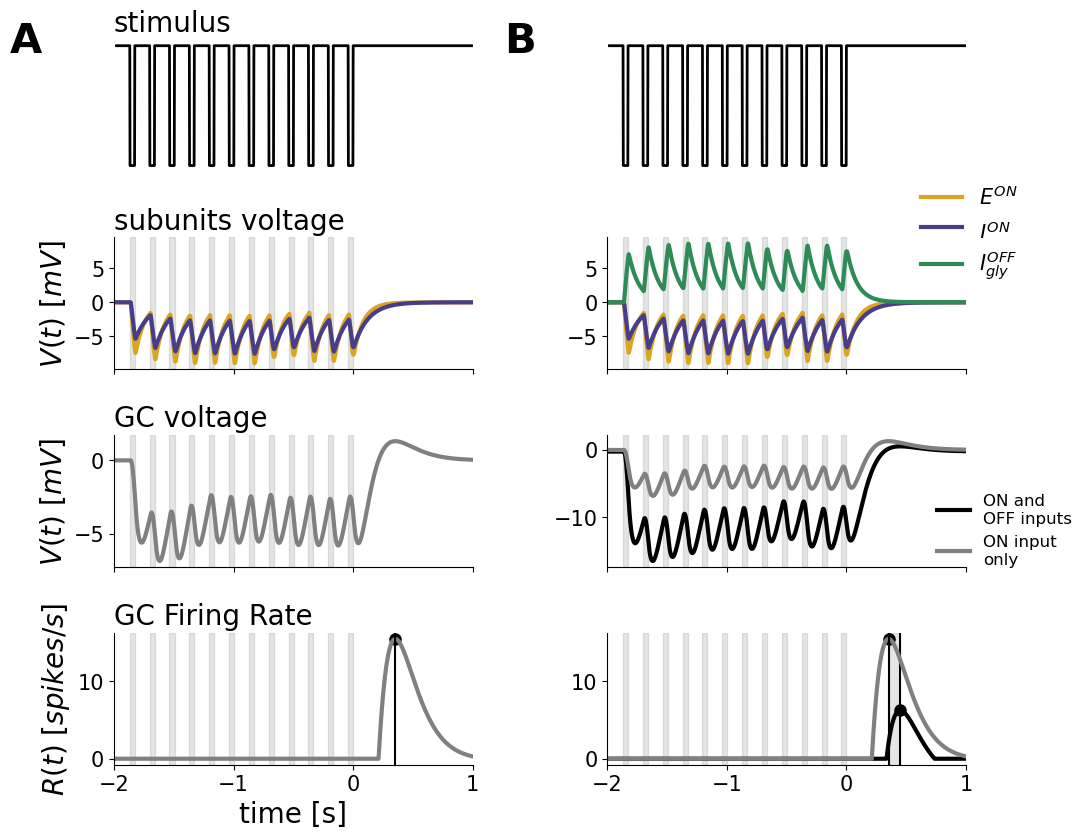

In [15]:



#####################################################################################################################
# panel A
#####################################################################################################################

#initialize figure
fig = plt.figure(figsize = figsize_2cols)
gs = fig.add_gridspec(4,2)
fig.patch.set_facecolor('white')

# fig.tight_layout()
fig.subplots_adjust(top=0.88,
bottom=0.11,
left=0.145,
right=0.95,
hspace=1,
wspace=0.5)

A = fig.add_subplot(gs[0:,0], frameon = False)
B = fig.add_subplot(gs[0:,1], frameon = False)


A0 = fig.add_subplot(gs[0,0]) # stimulus 
A1 = fig.add_subplot(gs[1,0],sharex = A0) # ON voltages
A3 = fig.add_subplot(gs[2,0],sharex = A0) # GC voltage
A4 = fig.add_subplot(gs[3,0],sharex = A0) # GC R(t)

B0 = fig.add_subplot(gs[0,1]) # stimulus 
B1 = fig.add_subplot(gs[1,1],sharex = A0, sharey = A1) # ON and OFF voltages
B3 = fig.add_subplot(gs[2,1],sharex = A0) # GC voltage
B4 = fig.add_subplot(gs[3,1],sharex = A0) # GC R(t)


# add panel labels
A.text(*panellabel_position, 'A', transform=A.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
B.text(*panellabel_position, 'B', transform=B.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


# remove frames that are not needed
A0.spines['right'].set_visible(False)
A0.spines['top'].set_visible(False)
A1.spines['right'].set_visible(False)
A1.spines['top'].set_visible(False)
A3.spines['right'].set_visible(False)
A3.spines['top'].set_visible(False)
A4.spines['right'].set_visible(False)
A4.spines['top'].set_visible(False)
B0.spines['right'].set_visible(False)
B0.spines['top'].set_visible(False)
B1.spines['right'].set_visible(False)
B1.spines['top'].set_visible(False)
B3.spines['right'].set_visible(False)
B3.spines['top'].set_visible(False)
B4.spines['right'].set_visible(False)
B4.spines['top'].set_visible(False)


#remove ticks
A.set_xticks([])
A.set_yticks([])
B.set_xticks([])
B.set_yticks([])

A0.spines['left'].set_color('white')
A0.tick_params(axis='y', colors='white')
A0.spines['bottom'].set_color('white')
A0.tick_params(axis='x', colors='white')
B0.spines['left'].set_color('white')
B0.tick_params(axis='y', colors='white')
B0.spines['bottom'].set_color('white')
B0.tick_params(axis='x', colors='white')

# set axis range
A0.set_xlim(-2,1.)
B0.set_xlim(-2,1.)



#label the axis
A1.set_ylabel('$V(t)$ $[mV] $',fontsize = fontsize_labels)
A3.set_ylabel('$V(t)$ $[mV] $',fontsize = fontsize_labels)
A4.set_ylabel('$R(t)$ $[spikes/s] $',fontsize = fontsize_labels)
A4.set_xlabel('time [s]', fontsize = fontsize_labels)

#label the axis
# B1.set_ylabel('$V(t)$',fontsize = fontsize_labels)
# B3.set_ylabel('$V(t)$',fontsize = fontsize_labels)
# B4.set_ylabel('$R(t)$',fontsize = fontsize_labels)
# B4.set_xlabel('time [s]', fontsize = fontsize_labels)


# set titles
A0.set_title('stimulus',fontsize = fontsize_labels, loc = 'left')
A1.set_title('subunits voltage ',fontsize = fontsize_labels, loc = 'left')
A3.set_title('GC voltage',fontsize = fontsize_labels, loc = 'left')
A4.set_title('GC Firing Rate',fontsize = fontsize_labels, loc = 'left')

# A1.set_title('ON voltages ',fontsize = fontsize_labels, loc = 'left')
# A3.set_title('GC voltage',fontsize = fontsize_labels, loc = 'left')
# A4.set_title('GC Firing Rate',fontsize = fontsize_labels, loc = 'left')

# B0.set_title('stimulus',fontsize = fontsize_labels, loc = 'left')
# B1.set_title('ON and OFF voltages',fontsize = fontsize_labels, loc = 'left')
# B3.set_title('GC voltage',fontsize = fontsize_labels, loc = 'left')
# B4.set_title('GC Firing Rate',fontsize = fontsize_labels, loc = 'left')



fig.subplots_adjust(top=0.835,
bottom=0.11,
left=0.11,
right=0.82,
hspace=0.5,
wspace=0.375)


#####################################################################################################################
# fill panels
#####################################################################################################################

### Stimulus traces

for ax in [A0,B0]:
    
    ax.plot(time_6Hz,stim_6Hz,color = 'k', linewidth = lw_stim)
    
    
### Inputs voltages

ax = A1
ax.plot(time_6Hz,VB_6Hz - VB_6Hz[0], color = 'goldenrod', linewidth = lw)
ax.plot(time_6Hz,VA2_6Hz - VA2_6Hz[100], color = 'darkslateblue', linewidth = lw)

ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelbottom=False)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)


ax = B1
ax.plot(time_6Hz,VB_6Hz - VB_6Hz[0], color = 'goldenrod', linewidth = lw, label = '$E^{ON}$')
ax.plot(time_6Hz,VA2_6Hz - VA2_6Hz[100], color = 'darkslateblue', linewidth = lw, label = '$I_{}^{ON}$')
ax.plot(time_6Hz,VA1_6Hz - VA1_6Hz[100], color = 'seagreen', linewidth = lw, label = '$I_{gly}^{OFF}$')

ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelbottom=False)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)

ax.legend(fontsize = fontsize_legend, frameon=False, loc=(.85,.6))
# panel 1 : how $B_{Glu}$ and $A_{GABA}$ make the peak


### GC voltage

ax = A3
ax.plot(time_6Hz,VG_fixed_6Hz, color = 'grey', linestyle = '-', linewidth = lw)

ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelbottom=False)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)

ax = B3
ax.plot(time_6Hz,VG_6Hz, color = 'black', linewidth = lw, label = 'ON and\nOFF inputs')
ax.plot(time_6Hz,VG_fixed_6Hz, color = 'grey', linestyle = '-', linewidth = lw,  label = 'ON input\nonly')
ax.legend(fontsize = (4/5)*fontsize_legend, frameon=False, loc=(.9,-0.05))

ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelbottom=False)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)


### GC firing rate

ax = A4
ax.plot(time_6Hz,RG_fixed_6Hz, color = 'grey', linestyle = '-', linewidth = lw)
ax.scatter(delay_fixed_6Hz,amp_fixed_6Hz, color = 'black', linewidth = lw)
ax.axvline(delay_fixed_6Hz, color = 'black') 
ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)

ax = B4
ax.plot(time_6Hz,RG_6Hz, color = 'black', linewidth = lw)
ax.scatter(delay_6Hz,amp_6Hz, color = 'black', linewidth = lw)
ax.axvline(delay_6Hz, color = 'black')
ax.locator_params(axis='x', nbins=3)
ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)



ax.plot(time_6Hz,RG_fixed_6Hz, color = 'grey', linestyle = '-', linewidth = lw)
ax.scatter(delay_fixed_6Hz,amp_fixed_6Hz, color = 'black', linewidth = lw)
ax.axvline(delay_fixed_6Hz, color = 'black') 
ax.axvspan(delay_6Hz,delay_fixed_6Hz, color = 'black', alpha = 0.1)



### Add stim shadings

for i in range(len(flashes_6Hz)):  
    if  not i % 2 :
        A1.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A3.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A4.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
    else:
        pass
      

for i in range(len(flashes_6Hz)):  
    if  not i % 2 :
        B1.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        B3.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        B4.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
    else:
        pass
      
### Legend

# fig.legend(fontsize = fontsize_legend, bbox_to_anchor = (1,.75), frameon=False)


### Save and plot

if save:
    plt.savefig(f"../Figures/{figure_name}")
if show:
    plt.show()
else:
    plt.close()